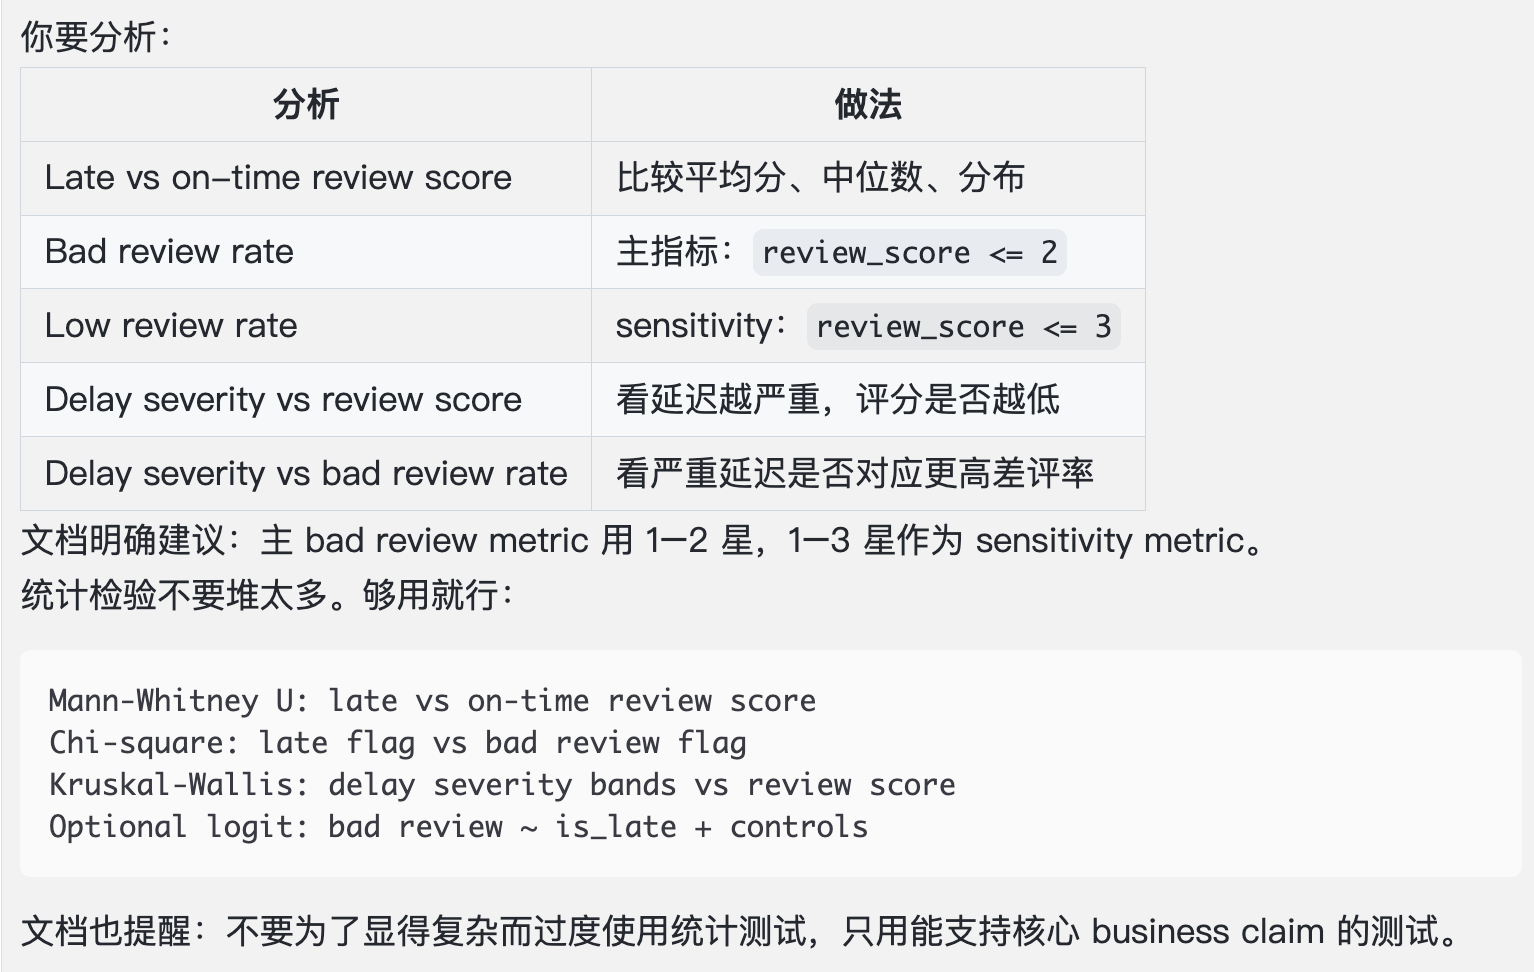

两个都参考：

Zeash + Moses
Gap Matrix 里写：

Zeash: Strong
Moses: Strong
Existing projects show relationship but stop at analytical conclusion
Your contribution: Use as core CX harm evidence and trigger for recovery design
所以这部分两个参考项目都重要。

搜索关键词
rg -n "review_score|bad_review|low_review|rating|satisfaction|late.*review|delay.*review|Mann|Whitney|Wilcoxon|Chi-square|chisq|Kruskal|OLS|logit|logistic" references/source_projects
你要找什么支撑？
找这些：

1. late vs on-time review score 怎么比较
2. bad review 怎么定义
3. 是否用了 1–2 星，还是 1–3 星
4. 是否做了统计检验
5. 最终 claim 是 association 还是 causation
你的指标要这样定
主指标：

bad_review = review_score <= 2
敏感性指标：

low_review = review_score <= 3
这个是 Gap Matrix 里明确写的：Zeash 用 1–2 stars，Moses 用 1–3 stars；你的项目要 main bad review = 1–2，optional sensitivity = 1–3。

你的额外动作
参考项目可能只是说：

late delivery is associated with lower review score
你要进一步写成：

This relationship is used as evidence of customer harm and becomes the trigger logic for service recovery design.
也就是说，你不止分析 review score，你要把它转成 recovery trigger。



# 03 Review Impact Analysis

## Business Objective

This notebook evaluates whether delivery failure is associated with customer dissatisfaction.

The purpose is not to prove causality.

The Olist dataset is observational, therefore this analysis measures association between delivery delay and customer experience outcomes.

The business question is:

> Should late delivery be treated as a customer experience early-warning signal?

This notebook extends previous delivery diagnosis by translating operational failure into customer harm evidence.

The analysis compares:

- Late delivery orders
- On-time / early delivery orders

using:

1. Review score differences
2. Bad review risk differences
3. Delay severity patterns
4. Statistical association tests

The findings will support the later service recovery design.


In [139]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from scipy.stats import kruskal


# 1. Analysis Population

The analysis uses delivered orders with:

- valid delivery timestamps;
- valid estimated delivery date;
- valid review score.

The population follows the delivery analysis definition established in previous notebooks.

Late delivery is treated using calendar dates rather than raw timestamps to avoid false late classification.


In [140]:
df = pd.read_csv(
    "../data/processed/master_order_table.csv"
)

df.shape


(99441, 43)

In [141]:
df.columns.tolist()


['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'item_count',
 'product_count',
 'seller_count',
 'category_count',
 'total_item_price',
 'total_freight_value',
 'is_multi_seller',
 'is_multi_category',
 'payment_record_count',
 'payment_type_count',
 'total_payment_value',
 'max_payment_installments',
 'payment_types',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'review_record_count',
 'has_multiple_reviews',
 'has_item_record',
 'has_payment_record',
 'has_review_record',
 'actual_delivery_date',
 'estimated_delivery_date',
 'delivery_analysis_eligible',
 'delay_days',
 'is_late',
 'is_late_timestamp_rule',
 'delay_band']

In [142]:
analysis_df = df[
    (df["order_status"]=="delivered")
    &
    (df["review_score"].notna())
    &
    (df["delay_days"].notna())
].copy()


analysis_df.shape


(95824, 43)

## Delivery Status

Late delivery:
delay_days > 0

On-time / Early:
delay_days <= 0

## Customer Dissatisfaction Signals
Primary metric:
bad_review = review_score <= 2
Reason:
1–2 star reviews represent stronger dissatisfaction.
Sensitivity metric:
low_review = review_score <= 3
Reason:
This follows alternative satisfaction grouping used in previous reference analysis.


In [143]:
analysis_df["delivery_status"] = np.where(
    analysis_df["delay_days"] > 0,
    "Late",
    "On-time/Early"
)


analysis_df["bad_review"] = (
    analysis_df["review_score"] <= 2
)


analysis_df["low_review"] = (
    analysis_df["review_score"] <= 3
)


analysis_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,actual_delivery_date,estimated_delivery_date,delivery_analysis_eligible,delay_days,is_late,is_late_timestamp_rule,delay_band,delivery_status,bad_review,low_review
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-10,2017-10-18,True,-8.0,False,False,on time or early,On-time/Early,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,2018-08-07,2018-08-13,True,-6.0,False,False,on time or early,On-time/Early,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,2018-08-17,2018-09-04,True,-18.0,False,False,on time or early,On-time/Early,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,2017-12-02,2017-12-15,True,-13.0,False,False,on time or early,On-time/Early,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,2018-02-16,2018-02-26,True,-10.0,False,False,on time or early,On-time/Early,False,False


# 3. Descriptive CX Impact

## Review Score Comparison


Question:

> Do late orders receive lower customer ratings?


Average review score provides the first indication of customer experience difference.

However, average scores alone do not measure dissatisfaction risk, therefore additional harm signals are analyzed later.


In [144]:
review_summary = (
    analysis_df
    .groupby("delivery_status")
    ["review_score"]
    .agg(
        orders="count",
        average_review_score="mean",
        median_review_score="median"
    )
    .reset_index()
)


review_summary


,delivery_status,orders,average_review_score,median_review_score
0,Late,6381,2.270491,1.0
1,On-time/Early,89443,4.290386,5.0


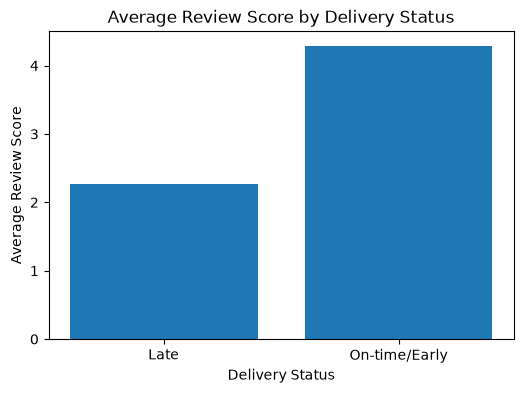

In [145]:
plt.figure(figsize=(6,4))

plt.bar(
    review_summary["delivery_status"],
    review_summary["average_review_score"]
)

plt.ylabel(
    "Average Review Score"
)

plt.xlabel(
    "Delivery Status"
)

plt.title(
    "Average Review Score by Delivery Status"
)

plt.show()


## Interpretation

If late orders receive lower review scores, this suggests delivery reliability is associated with weaker customer experience.

However, review score difference alone does not show the magnitude of customer harm.

Therefore, dissatisfaction risk metrics are analyzed next.


# 4. Customer Harm Signal Analysis
## Bad Review Risk
Customer dissatisfaction is operationalized as:
Bad Review = review_score <= 2

The analysis measures:
1. Bad review rate
2. Risk ratio
3. Risk difference
   
These metrics translate review impact into business-relevant customer harm signals.


In [146]:
bad_review_summary = (
    analysis_df
    .groupby("delivery_status")
    .agg(
        total_reviews=("review_score","count"),
        bad_reviews=("bad_review","sum")
    )
    .reset_index()
)


bad_review_summary["bad_review_rate"] = (
    bad_review_summary["bad_reviews"]
    /
    bad_review_summary["total_reviews"]
)


bad_review_summary


,delivery_status,total_reviews,bad_reviews,bad_review_rate
0,Late,6381,3983,0.624197
1,On-time/Early,89443,8289,0.092674


In [147]:
late_rate = (
    bad_review_summary
    .query("delivery_status=='Late'")
    ["bad_review_rate"]
    .iloc[0]
)


ontime_rate = (
    bad_review_summary
    .query("delivery_status=='On-time/Early'")
    ["bad_review_rate"]
    .iloc[0]
)


risk_ratio = late_rate / ontime_rate


risk_difference = late_rate - ontime_rate


print(
    "Risk Ratio:",
    round(risk_ratio,2)
)


print(
    "Risk Difference:",
    round(risk_difference*100,2),
    "percentage points"
)


Risk Ratio: 6.74
Risk Difference: 53.15 percentage points


## Sensitivity Analysis: Alternative Dissatisfaction Definition


Reference projects use different dissatisfaction thresholds:

- Zeash project:
  - bad review = review_score <= 2

- Moses project:
  - low review = review_score <= 3


Therefore, this project uses:

Primary metric:

    bad_review = review_score <= 2


Sensitivity metric:

    low_review = review_score <= 3


The purpose is to test whether the relationship between late delivery and dissatisfaction remains under a broader definition.


In [148]:
sensitivity_summary = (
    analysis_df
    .groupby("delivery_status")
    .agg(
        total_orders=("review_score","count"),
        bad_review_rate=("bad_review","mean"),
        low_review_rate=("low_review","mean")
    )
    .reset_index()
)


sensitivity_summary


,delivery_status,total_orders,bad_review_rate,low_review_rate
0,Late,6381,0.624197,0.732957
1,On-time/Early,89443,0.092674,0.173418


In [149]:
late_low_rate = (
    sensitivity_summary
    .query("delivery_status=='Late'")
    ["low_review_rate"]
    .iloc[0]
)


ontime_low_rate = (
    sensitivity_summary
    .query("delivery_status=='On-time/Early'")
    ["low_review_rate"]
    .iloc[0]
)


low_review_risk_ratio = (
    late_low_rate /
    ontime_low_rate
)


print(
    "Low review risk ratio (<=3 stars):",
    round(low_review_risk_ratio,2)
)


Low review risk ratio (<=3 stars): 4.23


## Interpretation


If both definitions show higher dissatisfaction risk among late deliveries:

- strong dissatisfaction (1–2 stars)
- broader dissatisfaction (1–3 stars)


then the relationship is less likely to depend on one arbitrary threshold.

This strengthens the interpretation that delivery reliability is associated with customer experience outcomes.


## 6. Mann-Whitney U Test


Question:

> Do late and on-time orders have different review score distributions?


Why Mann-Whitney:

Review score is an ordinal 1–5 rating scale.

The test compares whether the distributions of review scores differ between two independent delivery groups.


Null hypothesis:

Review score distributions are the same between late and on-time orders.


Alternative hypothesis:

Review score distributions differ between delivery groups.


In [150]:
late_scores = (
    analysis_df
    .query("delivery_status=='Late'")
    ["review_score"]
)


ontime_scores = (
    analysis_df
    .query("delivery_status=='On-time/Early'")
    ["review_score"]
)


mw_stat, mw_p = mannwhitneyu(
    late_scores,
    ontime_scores,
    alternative="two-sided"
)


print(
    "Mann-Whitney statistic:",
    mw_stat
)

print(
    "p-value:",
    mw_p
)


Mann-Whitney statistic: 103305546.0
p-value: 0.0


In [151]:
if mw_p < 0.05:
    print(
        "Review score distributions differ significantly between delivery groups."
    )
else:
    print(
        "No statistically significant difference detected."
    )


Review score distributions differ significantly between delivery groups.


## 7. Chi-square Test


Question:

> Is late delivery associated with a higher probability of bad reviews?


Variables:

Delivery status:

- Late
- On-time/Early


Customer outcome:

- Bad review
- Not bad review


Null hypothesis:

Delivery status and bad review occurrence are independent.


Alternative hypothesis:

Delivery status and bad review occurrence are associated.


In [152]:
contingency = pd.crosstab(
    analysis_df["delivery_status"],
    analysis_df["bad_review"]
)


contingency


bad_review,False,True
delivery_status,,
Late,2398,3983
On-time/Early,81154,8289


In [153]:
chi2, chi_p, dof, expected = chi2_contingency(
    contingency
)


print(
    "Chi-square statistic:",
    chi2
)


print(
    "p-value:",
    chi_p
)


Chi-square statistic: 15064.148966139202
p-value: 0.0


In [154]:
if chi_p < 0.05:
    print(
        "Bad review occurrence is significantly associated with delivery status."
    )
else:
    print(
        "No significant association detected."
    )


Bad review occurrence is significantly associated with delivery status.


# Optional Robustness Check

## Logistic Regression


This analysis is included as a robustness check.

The main evidence in this notebook comes from:

- Review score comparison
- Bad review risk analysis
- Mann-Whitney U test
- Chi-square test
- Delay severity analysis


The logistic regression provides additional validation by examining whether late delivery remains associated with bad review probability after controlling for observable order characteristics.


The model estimates:

bad_review ~ is_late + operational controls


Control variables include:

- total item price
- freight value
- item quantity
- seller complexity
- category complexity


Important limitation:

This model does not prove causal impact.

Because the Olist dataset is observational, results should be interpreted as association:

"Late delivery remains associated with higher bad review probability after accounting for observable factors."


Unobserved factors such as customer expectations, communication quality, and logistics events are not included.


In [155]:
import statsmodels.formula.api as smf
import numpy as np


model_df = analysis_df[
    [
        "bad_review",
        "is_late",
        "total_item_price",
        "total_freight_value",
        "item_count",
        "seller_count",
        "category_count"
    ]
].dropna().copy()


model_df["bad_review"] = (
    model_df["bad_review"]
    .astype(int)
)


model_df["is_late"] = (
    model_df["is_late"]
    .astype(int)
)


model_df.dtypes



bad_review               int64
is_late                  int64
total_item_price       float64
total_freight_value    float64
item_count             float64
seller_count           float64
category_count         float64
dtype: object

In [156]:
logit_model = smf.logit(
    """
    bad_review ~
    is_late
    + total_item_price
    + total_freight_value
    + item_count
    + seller_count
    + category_count
    """,
    data=model_df
).fit()


logit_model.summary()


Optimization terminated successfully.
         Current function value: 0.321399
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             bad_review   No. Observations:                95824
Model:                          Logit   Df Residuals:                    95817
Method:                           MLE   Df Model:                            6
Date:                Sun, 27 Sep 2026   Pseudo R-squ.:                  0.1602
Time:                        10:12:48   Log-Likelihood:                -30798.
converged:                       True   LL-Null:                       -36672.
Covariance Type:            nonrobust   LLR p-value:                     0.000
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -4.5163      0.082    -55.111      0.000      -4.677      -4.356
is_late                 2.8851      0.029    100.475      0.000       2.829       2.941
total_item_price        0.0002    5.1e-05      3.028      0.002    5.45e-05       0.000
total_freight_value     0.0020      0.001      3.757      0.000       0.001       0.003
item_count              0.4303      0.018     23.324      0.000       0.394       0.466
seller_count            1.4798      0.076     19.582      0.000       1.332       1.628
category_count          0.1146      0.100      1.149      0.251      -0.081       0.310
=======================================================================================
"""

In [157]:
odds_ratio = np.exp(
    logit_model.params
)


odds_ratio.sort_values(
    ascending=False
)


is_late                17.906122
seller_count            4.391891
item_count              1.537777
category_count          1.121429
total_freight_value     1.002027
total_item_price        1.000154
Intercept               0.010930
dtype: float64

## Interpretation


The logistic regression provides robustness evidence.

The odds ratio of `is_late` shows whether late delivery remains associated with bad review probability after controlling for observable order characteristics.


An odds ratio above 1 indicates higher odds of receiving a bad review among late delivery orders, holding other included variables constant.


This strengthens the customer harm evidence used for recovery trigger design.

However, the model does not establish causal impact because other unobserved customer experience factors may influence review outcomes.


## 8. Delay Severity and Customer Experience


Late delivery is not a binary problem.

A one-day delay and a thirty-day delay may create different levels of customer dissatisfaction.


Therefore, this analysis evaluates whether increasing delay severity corresponds to worsening review outcomes.


In [158]:
bins=[
    -999,
    0,
    3,
    7,
    14,
    30,
    999
]


labels=[
    "On-time/Early",
    "1-3 days late",
    "4-7 days late",
    "8-14 days late",
    "15-30 days late",
    "30+ days late"
]


analysis_df["delay_band"] = pd.cut(
    analysis_df["delay_days"],
    bins=bins,
    labels=labels
)


analysis_df["delay_band"].value_counts()


delay_band
On-time/Early      89443
1-3 days late       1852
4-7 days late       1748
8-14 days late      1446
15-30 days late     1006
30+ days late        329
Name: count, dtype: int64

In [159]:
severity_summary = (
    analysis_df
    .groupby(
        "delay_band",
        observed=True
    )
    .agg(
        orders=("review_score","count"),
        average_review_score=("review_score","mean"),
        bad_review_rate=("bad_review","mean")
    )
    .reset_index()
)


severity_summary


,delay_band,orders,average_review_score,bad_review_rate
0,On-time/Early,89443,4.290386,0.092674
1,1-3 days late,1852,3.291037,0.321274
2,4-7 days late,1748,2.102975,0.676773
3,8-14 days late,1446,1.670816,0.801521
4,15-30 days late,1006,1.614314,0.818091
5,30+ days late,329,2.057751,0.677812


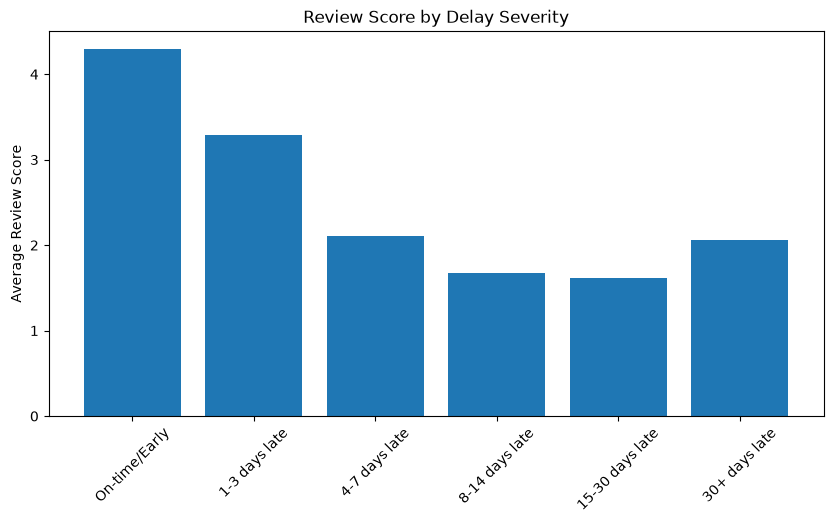

In [160]:
plt.figure(figsize=(10,5))


plt.bar(
    severity_summary["delay_band"].astype(str),
    severity_summary["average_review_score"]
)


plt.xticks(
    rotation=45
)


plt.ylabel(
    "Average Review Score"
)


plt.title(
    "Review Score by Delay Severity"
)


plt.show()


In [161]:
severity_groups = [
    group["review_score"].values
    for name, group
    in analysis_df.groupby(
        "delay_band",
        observed=True
    )
]


kruskal_stat, kruskal_p = kruskal(
    *severity_groups
)


print(
    "Kruskal-Wallis statistic:",
    kruskal_stat
)


print(
    "p-value:",
    kruskal_p
)


Kruskal-Wallis statistic: 10119.654793870715
p-value: 0.0


## Interpretation


A significant Kruskal-Wallis result indicates that review score distributions differ across delay severity groups.


The pattern is important for service recovery design:

Small delays may require communication and expectation management.

Severe delays may require escalation, compensation consideration, or priority intervention.


Therefore, delay severity can be used as a recovery prioritization signal.


# 9. Recovery Trigger Translation


The purpose of this analysis is not only to identify statistical relationships.

The findings are translated into operational recovery logic.


Evidence chain:

Delivery failure

↓

Customer harm signal

↓

Recovery trigger

↓

Operational action


## Recovery Trigger Framework


| Evidence Signal | Customer Risk Interpretation | Recovery Action |
|---|---|---|
| Late delivery detected | Delivery promise failure | proactive delay notification |
| Higher bad review probability | Increased dissatisfaction risk | recovery outreach |
| Severe delay band | Escalating customer harm | priority escalation |
| High-risk seller pattern | Repeated operational failure | seller governance intervention |
| High-risk category/region | Structural delivery weakness | targeted improvement plan |


This converts analytical findings into a service recovery operating model.


# 10. CX Impact Summary


## Evidence 1: Review Score Impact

Late delivery orders received a lower average review score (2.27) compared with on-time/early orders (4.29).



## Evidence 2: Customer Harm Signal
Late orders showed a bad review rate of 62.4%, compared with 9.3% for on-time/early orders.

This represents a 6.74x higher bad review risk and a 53.15 percentage point difference.



## Evidence 3: Robustness

The logistic regression shows that late delivery remains associated with higher bad review odds after controlling for order characteristics.

The estimated odds ratio for is_late is approximately 17.9.



## Evidence 4: Severity Pattern

Kruskal-Wallis testing indicates that review score distributions differ across delay severity groups.

This supports differentiated recovery actions based on delay severity.


## Business Implication


Delivery failure should not only be monitored as an operational KPI.

It can be treated as an early-warning signal for customer dissatisfaction and a trigger for proactive service recovery.


## Limitation


This analysis identifies association rather than causal impact.

Other factors such as seller performance, product category, logistics conditions, and customer expectations may also influence review outcomes.


The recovery system proposed later requires future validation through operational testing.
